In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('customer_segmentation_discount.csv')
df.head()

,user_id,age,gender,annual_income,device_mobile,traffic_source,product_category,current_session_duration_sec,time_spent_deviation,pages_viewed,...,checked_delivery_pdp,saw_checkout,sign_in,is_returning_user,lifetime_purchases_count,customer_conversion_rate,days_since_last_discount,previous_review_sentiment,social_channels_followed_count,should_receive_discount
0,usr_0001,56,0,33225.49,1,1,1,105.9,-32.8,4,...,0,0,0,0,0,0.005,999,1,1,1
1,usr_0002,46,1,65798.72,1,3,2,167.1,-18.4,4,...,0,1,1,1,3,0.150,5,1,4,0
2,usr_0003,32,0,82553.51,1,1,0,96.6,-118.1,2,...,0,1,0,0,0,0.005,999,1,1,1
3,usr_0004,60,1,76937.71,0,4,1,53.0,-166.9,1,...,0,1,0,0,0,0.005,999,1,1,1
4,usr_0005,25,1,51158.03,1,2,0,180.4,-3.3,3,...,1,1,1,1,4,0.211,30,2,0,0


In [3]:
df.columns

Index(['user_id', 'age', 'gender', 'annual_income', 'device_mobile',
       'traffic_source', 'product_category', 'current_session_duration_sec',
       'time_spent_deviation', 'pages_viewed', 'basket_icon_click',
       'cart_items_count_this_session', 'cart_total_value',
       'scrolled_to_reviews', 'checked_delivery_pdp', 'saw_checkout',
       'sign_in', 'is_returning_user', 'lifetime_purchases_count',
       'customer_conversion_rate', 'days_since_last_discount',
       'previous_review_sentiment', 'social_channels_followed_count',
       'should_receive_discount'],
      dtype='str')

In [4]:
df.isnull().sum()

user_id                           0
age                               0
gender                            0
annual_income                     0
device_mobile                     0
traffic_source                    0
product_category                  0
current_session_duration_sec      0
time_spent_deviation              0
pages_viewed                      0
basket_icon_click                 0
cart_items_count_this_session     0
cart_total_value                  0
scrolled_to_reviews               0
checked_delivery_pdp              0
saw_checkout                      0
sign_in                           0
is_returning_user                 0
lifetime_purchases_count          0
customer_conversion_rate          0
days_since_last_discount          0
previous_review_sentiment         0
social_channels_followed_count    0
should_receive_discount           0
dtype: int64

In [5]:
df.shape

(1000, 24)

In [6]:
df.drop('user_id', axis=1, inplace=True)

In [7]:
df.drop('should_receive_discount', axis=1, inplace=True)


In [8]:
df.dtypes

age                                 int64
gender                              int64
annual_income                     float64
device_mobile                       int64
traffic_source                      int64
product_category                    int64
current_session_duration_sec      float64
time_spent_deviation              float64
pages_viewed                        int64
basket_icon_click                   int64
cart_items_count_this_session       int64
cart_total_value                  float64
scrolled_to_reviews                 int64
checked_delivery_pdp                int64
saw_checkout                        int64
sign_in                             int64
is_returning_user                   int64
lifetime_purchases_count            int64
customer_conversion_rate          float64
days_since_last_discount            int64
previous_review_sentiment           int64
social_channels_followed_count      int64
dtype: object

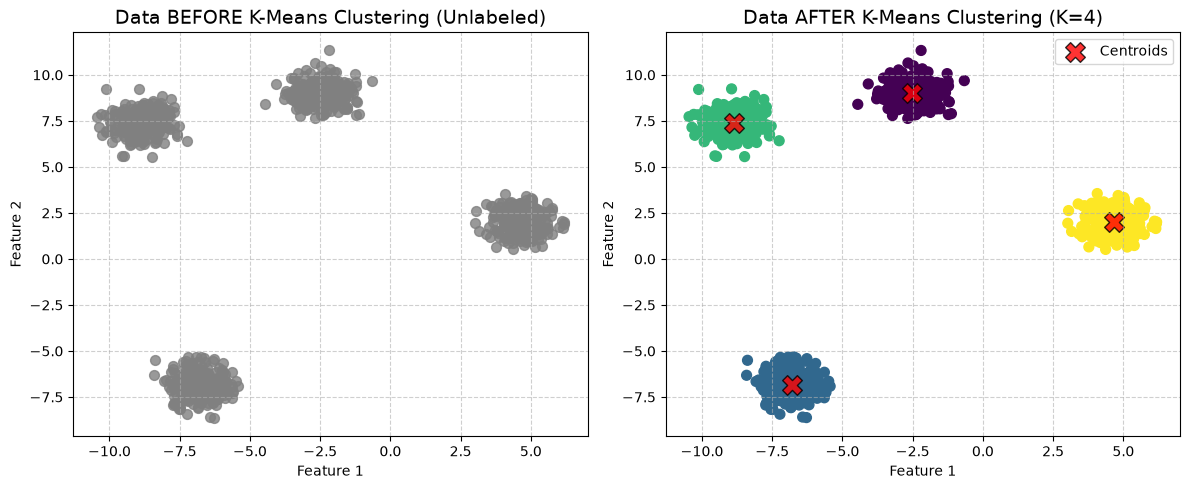


--- K-Means Results ---
The final coordinates of the 4 centroids are:
Cluster 0 Centroid: (-2.51, 9.02)
Cluster 1 Centroid: (-6.80, -6.84)
Cluster 2 Centroid: (-8.86, 7.38)
Cluster 3 Centroid: (4.65, 2.01)

Inertia (WCSS): 702.11
Runtime: 0.013979911804199219 seconds


In [15]:
import time


import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# --- 1. Data Generation ---
# Generate a synthetic dataset with 3 clear 'blobs' (clusters)
# n_samples: total number of points
# centers: the number of clusters (K)
# random_state: for reproducibility

start_time = time.time()
n_samples = len(df)
random_seed = 42
K_clusters = 4

X, y_true = make_blobs(n_samples=len(df), centers=K_clusters,
                       cluster_std=0.60, random_state=random_seed)

# X contains the (x, y) coordinates of the data points
# y_true contains the true labels (which we ignore in K-Means, as it's unsupervised)

# --- 2. Visualization: Data BEFORE K-Means ---
plt.figure(figsize=(12, 5))

# Subplot 1: Unlabeled Data
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray', alpha=0.8)
plt.title('Data BEFORE K-Means Clustering (Unlabeled)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)

# --- 3. K-Means Implementation ---
# 1. Initialize the K-Means model
#    n_clusters=K_clusters: The 'K' value we chose (3)
#    init='k-means++': Smart initialization to speed up convergence
#    n_init='auto': Runs K-Means multiple times and returns the best one
kmeans = KMeans(n_clusters=K_clusters, init='random', n_init='auto', random_state=random_seed)

# 2. Fit the model to the data (this runs the iterative assignment and update steps)
kmeans.fit(X)

# 3. Get the results
y_kmeans = kmeans.predict(X)          # The cluster labels (0, 1, or 2) for each point
centers = kmeans.cluster_centers_     # The final coordinates of the 3 centroids

end_time = time.time()
plt.subplot(1, 2, 2)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X',
            edgecolor='black', label='Centroids')

plt.title(f'Data AFTER K-Means Clustering (K={K_clusters})', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n--- K-Means Results ---")
print(f"The final coordinates of the {K_clusters} centroids are:")
for i, center in enumerate(centers):
    print(f"Cluster {i} Centroid: ({center[0]:.2f}, {center[1]:.2f})")
print(f"\nInertia (WCSS): {kmeans.inertia_:.2f}")



print("Runtime:", end_time - start_time, "seconds")

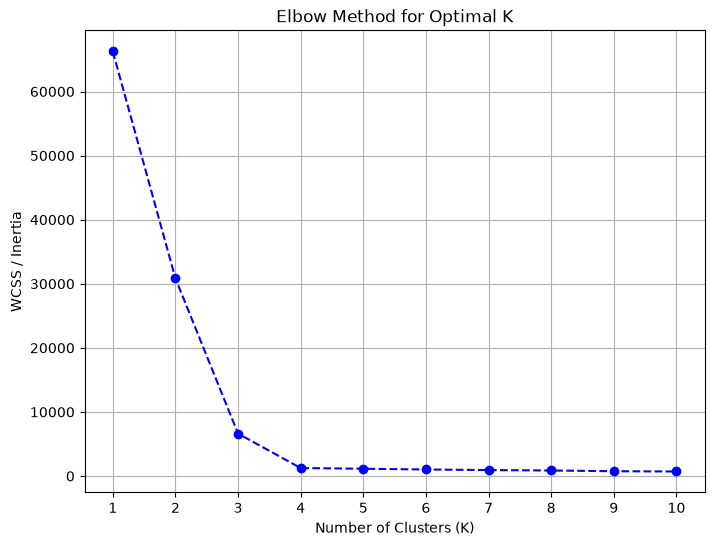

WCSS values for K=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]: [66242.3674403603, 30840.913967300687, 6620.393694543897, 1248.1970289207807, 1136.3323618726324, 1019.6086487597229, 931.7300217575669, 865.8433457129632, 750.7044916602715, 707.427140033519]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# --- 1. Data Generation (For demonstration) ---
# Generate a dataset with 4 clear clusters
X, y_true = make_blobs(n_samples=len(df), centers=4,
                       cluster_std=0.8, random_state=42)

# --- 2. Implement the Elbow Method ---
k_range = range(1, 11)
wcss = [] # To store WCSS (Inertia) for each K

for k in k_range:
    # Initialize K-Means with the current K
    kmeans = KMeans(n_clusters=k, init='random', n_init='auto',
                    random_state=42, max_iter=300)
    kmeans.fit(X)

    # Get the WCSS (Inertia) value
    wcss.append(kmeans.inertia_)

# --- 3. Plot the Elbow Curve ---
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Print WCSS values for inspection
print(f"WCSS values for K={list(k_range)}: {wcss}")